# Ingredient Scanner: Person 2 (Deep Learning NER) and Person 3 (OCR, knowledge base, app)

This notebook continues `ingredient_scanner_person1_pipeline.ipynb`, which built the data foundation.
Here we:
- train and compare NER models (dictionary rules, CRF, DistilBERT, DistilBERT with OCR-noise augmentation, DistilBERT + CRF, BERT-base);
- build the OCR pipeline, knowledge base and entity linking;
- connect everything into the photo-to-result app.

```
PACKET IMAGE → OCR (RapidOCR PP-OCRv6, auto-enlarge, orientation) → SPELLING CORRECTION (food dictionary)
→ code clean-up → INGREDIENTS SECTION → NORMALISATION → HYBRID NER (rules + DistilBERT + fuzzy KB)
→ ENTITY LINKING (knowledge base) → CATEGORY SUMMARY + ALLERGENS + NUTRITION → DAILY INTAKE GUIDE
```

**Honesty note.**
- All models are trained on **silver** (rule-made) labels.
- *silver test* scores measure how well a model learned the labelling policy.
- *noisy test* scores measure robustness to OCR-style errors, the realistic setting.
- The *real photos* evaluation measures the full pipeline on 60 real packet photos.
- **No human-verified gold labels exist yet.** Gold scores appear automatically after annotation.

In [1]:
import os, sys, json
from pathlib import Path
ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
os.chdir(ROOT); sys.path.insert(0, str(ROOT))
import warnings; warnings.filterwarnings("ignore")
import pandas as pd
from IPython.display import Image, Markdown, HTML, display
pd.set_option("display.max_colwidth", 110)
def load(path): return json.loads(Path(path).read_text(encoding="utf-8"))

## Part A: Person 2, Deep Learning NER

### A1. Pretrained models

| Model | Parameters | Source |
|---|---|---|
| `distilbert-base-uncased` | 66 M | Sanh et al. 2019, Hugging Face's original public S3 bucket |
| `bert-base-cased` | 108 M | Devlin et al. 2019, same source |

`src/ner/pretrained.py` downloads them with plain HTTPS. The project therefore also works where huggingface.co is blocked.

### A2. From word labels to sub-word labels

In [2]:
from transformers import AutoTokenizer
from src.ner.transformer_ner import encode, IGNORE
from src.labeling.bio import ID2LABEL
tok = AutoTokenizer.from_pretrained("models/ingredient-ner-distilbert")
words = ["Maltodextrin", ",", "Acidity", "regulator", "(", "INS", "330", ")"]
tags  = ["B-INGREDIENT", "O", "B-FUNCTION_CLASS", "I-FUNCTION_CLASS", "O", "B-INS_CODE", "I-INS_CODE", "O"]
item = encode(tok, words, tags)
pd.DataFrame({"sub-word": tok.convert_ids_to_tokens(item["input_ids"]),
              "training label": [ID2LABEL[l] if l != IGNORE else "-100 (ignored)" for l in item["labels"]]}).T

,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14
sub-word,[CLS],mal,##to,##de,##xt,##rin,",",acid,##ity,regulator,(,ins,330,),[SEP]
training label,-100 (ignored),B-INGREDIENT,-100 (ignored),-100 (ignored),-100 (ignored),-100 (ignored),O,B-FUNCTION_CLASS,-100 (ignored),I-FUNCTION_CLASS,O,B-INS_CODE,I-INS_CODE,O,-100 (ignored)


> **WHAT WE DID:** Each word's first sub-word gets the word's label; other sub-words and the special tokens [CLS]/[SEP] get -100, which the loss ignores.
>
> **WHY:** The Transformer predicts one label per sub-word, but our data and evaluation are per word.
>
> **INPUT → OUTPUT:** word tokens + BIO tags → sub-word ids + aligned label ids
>
> **HOW TO EXPLAIN IT IN THE VIVA:** *"We follow the standard Hugging Face token-classification recipe and predict each word from its first sub-word, so scores stay comparable at word level."*

### A3. Training runs (same seeded 8,000 silver sentences for every learned model)

In [3]:
rows = []
for log_path in sorted(Path("models/runs").glob("*/best/training_log.json")):
    log = load(log_path); a = log["args"]
    rows.append({"run": log_path.parent.parent.name, "base model": a["model"], "CRF head": a["crf"], "OCR augmentation": a["augment"],
                 "epochs": a["epochs"], "lr": a["lr"], "train sentences": a["max_train"],
                 "val F1 per epoch": [e["val_f1"] for e in log["epochs"]], "minutes": log["epochs"][-1]["minutes"]})
crf_info = Path("models/crf/training_info.json")
if crf_info.exists():
    info = load(crf_info)
    rows.append({"run": "crf", "base model": "none (hand-made features)", "CRF head": True, "OCR augmentation": False,
                 "epochs": f"{info['max_iterations']} L-BFGS iterations", "lr": "-", "train sentences": info["train_sentences"],
                 "val F1 per epoch": "-", "minutes": round(info["seconds"] / 60, 1)})
pd.DataFrame(rows)

,run,base model,CRF head,OCR augmentation,epochs,lr,train sentences,val F1 per epoch,minutes
0,crf,none (hand-made features),True,False,150 L-BFGS iterations,-,8000,-,1.9


Hyper-parameters (`src/ner/transformer_ner.py`):
- AdamW, weight decay 0.01;
- linear warm-up (10%) then decay; gradient clipping 1.0;
- batch 16, max 256 sub-words, length-bucketed batches;
- best epoch chosen on silver validation.

Training ran on a 4-core CPU with no GPU, which is why we use 8,000 sentences and 2 epochs for every model.

### A4. Comparison: Dictionary vs CRF vs DistilBERT vs BERT

,silver_test,noisy_test_0.05,noisy_test_0.10,sentences_per_second
dictionary,1.000,0.862,0.734,1113.9
crf,0.949,0.872,0.796,664.0
bert,0.929,0.852,0.767,14.4
distilbert,0.943,0.834,0.719,46.9
distilbert_aug,0.940,0.922,0.900,44.5
distilbert_crf,0.950,0.851,0.747,48.3


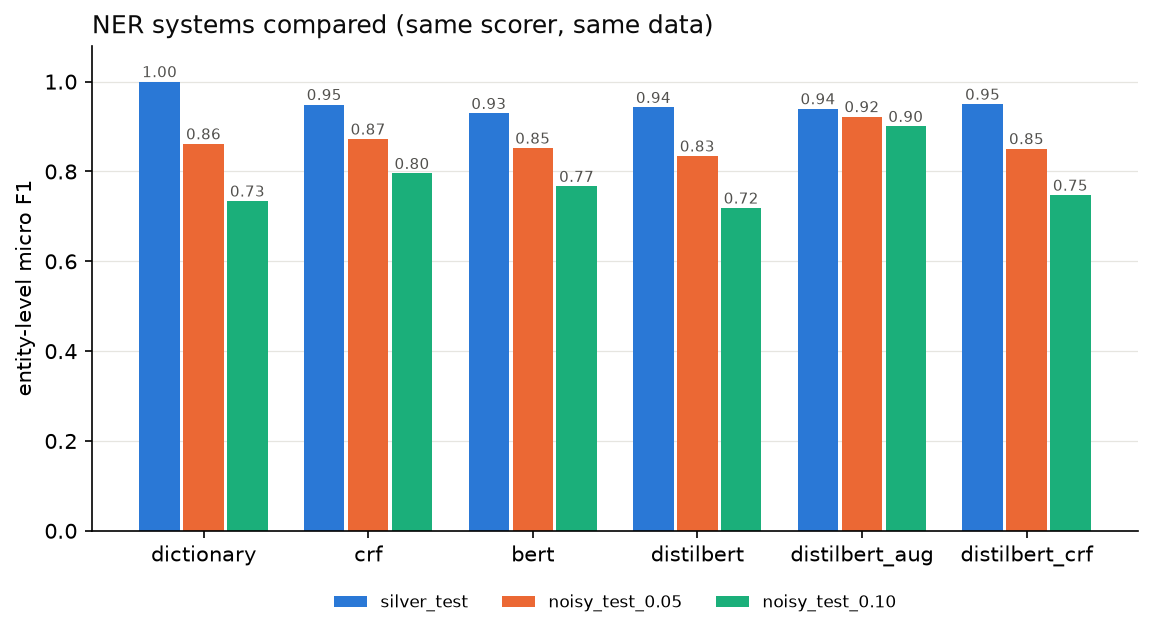

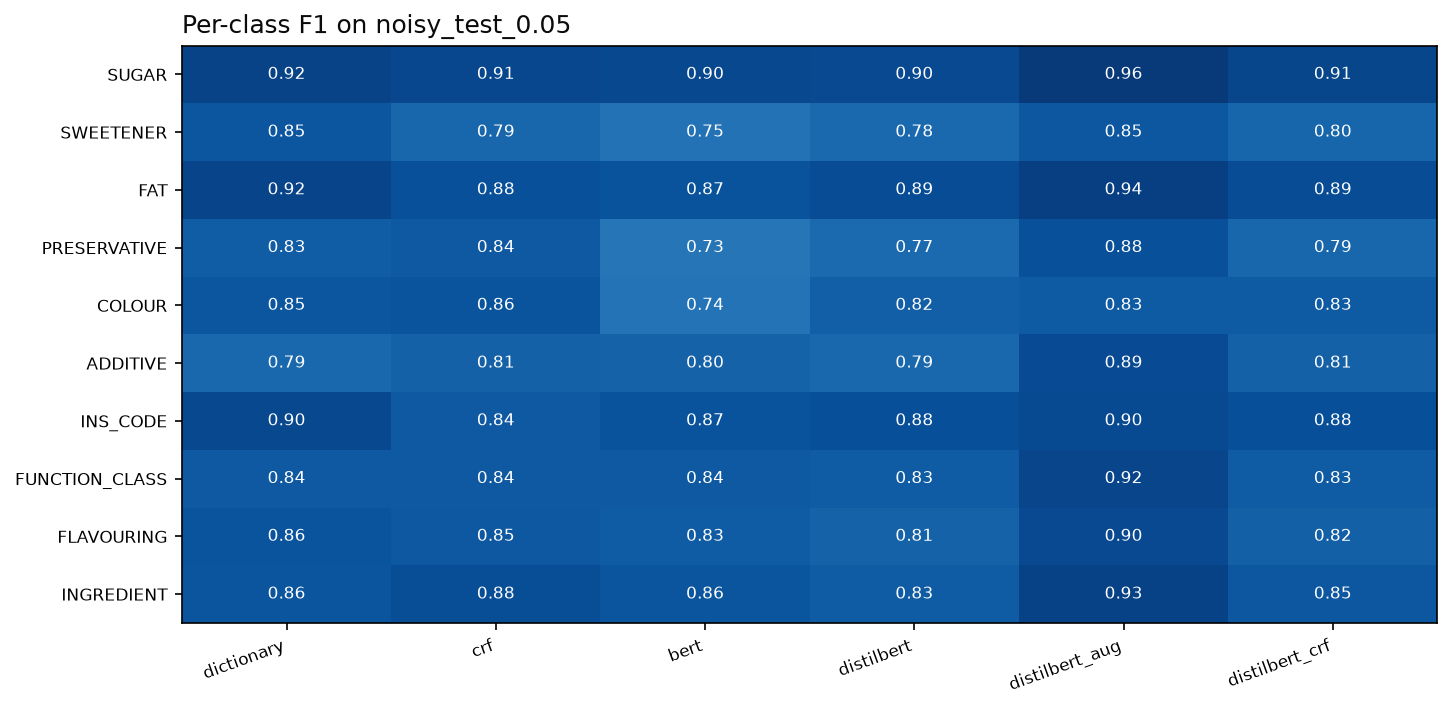

In [4]:
comparison = load("reports/model_comparison.json")
summary = pd.DataFrame(comparison["summary_f1"]).T
display(summary.round(3))
display(Image("reports/figures/12_model_comparison.png", width=900))
display(Image("reports/figures/13_per_class_f1_noisy.png", width=800))

How to read this:
* **silver_test.** The dictionary is 1.0 by construction, because silver labels *are* its output. A learned
  model close to 1.0 has learned the labelling policy and generalises it to unseen products.
* **noisy_test.** Same products with OCR-style character errors. The dictionary drops sharply because exact
  string matching fails. Models that learned from context hold up better, and the OCR-augmented model is
  trained for exactly this.
* **gold_test.** The real benchmark, available after the team's annotation.

In [5]:
details = comparison["details"]
best = max((m for m in details if m != "dictionary"), key=lambda m: details[m]["noisy_test_0.05"]["micro"]["f1"])
from src.evaluation.metrics import format_report
print("Best system on noisy text:", best)
display(Markdown(format_report(details[best]["noisy_test_0.05"], f"{best} on noisy_test_0.05")))
display(Markdown(format_report(details["dictionary"]["noisy_test_0.05"], "dictionary on noisy_test_0.05")))

Best system on noisy text: distilbert_aug


### distilbert_aug on noisy_test_0.05

| Class | Precision | Recall | F1 | Support |
|---|---:|---:|---:|---:|
| SUGAR | 0.960 | 0.969 | 0.965 | 1150 |
| SWEETENER | 0.879 | 0.820 | 0.849 | 89 |
| FAT | 0.922 | 0.959 | 0.940 | 950 |
| PRESERVATIVE | 0.861 | 0.890 | 0.875 | 146 |
| COLOUR | 0.808 | 0.863 | 0.834 | 219 |
| ADDITIVE | 0.849 | 0.938 | 0.891 | 1444 |
| INS_CODE | 0.832 | 0.971 | 0.896 | 697 |
| FUNCTION_CLASS | 0.888 | 0.949 | 0.917 | 1091 |
| FLAVOURING | 0.887 | 0.917 | 0.902 | 581 |
| INGREDIENT | 0.914 | 0.941 | 0.927 | 9760 |
| **overall (micro)** | **0.902** | **0.943** | **0.922** | 16127 |
| macro F1 | | | 0.900 | |
| partial match (micro) | 0.924 | 0.966 | 0.945 | |

### dictionary on noisy_test_0.05

| Class | Precision | Recall | F1 | Support |
|---|---:|---:|---:|---:|
| SUGAR | 0.984 | 0.867 | 0.922 | 1150 |
| SWEETENER | 1.000 | 0.742 | 0.852 | 89 |
| FAT | 0.982 | 0.864 | 0.919 | 950 |
| PRESERVATIVE | 0.981 | 0.712 | 0.825 | 146 |
| COLOUR | 0.988 | 0.753 | 0.855 | 219 |
| ADDITIVE | 0.956 | 0.668 | 0.787 | 1444 |
| INS_CODE | 0.967 | 0.849 | 0.904 | 697 |
| FUNCTION_CLASS | 0.975 | 0.742 | 0.843 | 1091 |
| FLAVOURING | 0.966 | 0.778 | 0.862 | 581 |
| INGREDIENT | 0.963 | 0.774 | 0.858 | 9760 |
| **overall (micro)** | **0.967** | **0.777** | **0.862** | 16127 |
| macro F1 | | | 0.863 | |
| partial match (micro) | 0.974 | 0.782 | 0.868 | |

### A5. Side by side on OCR-like text

In [6]:
from src.baseline.dictionary_ner import DictionaryNER
from src.ner.transformer_ner import TransformerTagger
model = TransformerTagger("models/ingredient-ner-distilbert")
rules = DictionaryNER()
examples = ["Sugar, lnvert syrup, ref1ned pa1m oil, Emu1sifier (INS 322), Acidity regu1ator (330), dextr0se",
            "WHEAT FLOUR SUGAR PALM OIL INVERT SUGAR SYRUP MILK SOLIDS EMULSIFIER 471 COLOUR 150d"]
for text in examples:
    print(text)
    for name, system in (("rules", rules), ("DistilBERT", model)):
        ents = system.predict(text)["entities"]
        print(f"  {name:10}", [(e["text"], e["label"]) for e in ents])

Loading weights:   0%|          | 0/102 [00:00<?, ?it/s]

Loading weights:   6%|▌         | 6/102 [00:00<00:03, 28.71it/s]

Loading weights: 100%|██████████| 102/102 [00:00<00:00, 432.15it/s]

Sugar, lnvert syrup, ref1ned pa1m oil, Emu1sifier (INS 322), Acidity regu1ator (330), dextr0se
  rules      [('Sugar', 'SUGAR'), ('lnvert syrup', 'SUGAR'), ('ref1ned pa1m oil', 'FAT'), ('INS 322', 'INS_CODE'), ('330', 'INS_CODE')]
  DistilBERT [('Sugar', 'SUGAR'), ('lnvert syrup', 'SUGAR'), ('ref1ned pa1m oil', 'FAT'), ('Emu1sifier', 'FUNCTION_CLASS'), ('INS 322', 'INS_CODE'), ('Acidity regu1ator', 'FUNCTION_CLASS'), ('330', 'INS_CODE'), ('dextr0se', 'SUGAR')]
WHEAT FLOUR SUGAR PALM OIL INVERT SUGAR SYRUP MILK SOLIDS EMULSIFIER 471 COLOUR 150d
  rules      [('EMULSIFIER', 'FUNCTION_CLASS'), ('471', 'INS_CODE'), ('COLOUR', 'FUNCTION_CLASS'), ('150d', 'INS_CODE')]
  DistilBERT [('SOLIDS', 'FUNCTION_CLASS'), ('EMULSIFIER', 'FUNCTION_CLASS'), ('471', 'INS_CODE'), ('COLOUR', 'FUNCTION_CLASS'), ('150d', 'INS_CODE')]


> **WHAT WE DID:** Trained DistilBERT/BERT token classifiers (plus a CRF head and an OCR-noise-augmented variant) on silver data and compared them with the rules and a feature-based CRF using one scorer.
>
> **WHY:** The dictionary is precise on clean text but brittle: OCR errors and missing commas break exact matching. A pretrained Transformer uses context, so it can still recognise 'lnvert syrup' as a sugar.
>
> **INPUT → OUTPUT:** silver training data → fine-tuned models + comparison tables
>
> **HOW TO EXPLAIN IT IN THE VIVA:** *"Weak supervision: the model is trained on rule labels and then has to generalise beyond the rules. We show this on noisy text where the rules fail, and the final benchmark is the human gold set."*

### A6. Error analysis of the models

In [7]:
rows = []
for f in sorted(Path("reports/error_analysis").glob("*_errors_noisy_test_0.05.csv")):
    e = pd.read_csv(f)
    rows.append({"system": f.name.split("_errors")[0], **e["error_type"].value_counts().to_dict(), "total": len(e)})
display(pd.DataFrame(rows).fillna(0).set_index("system"))
errors = pd.read_csv(f"reports/error_analysis/{best}_errors_noisy_test_0.05.csv")
display(errors.sample(min(12, len(errors)), random_state=0)[["text", "expected_entity", "expected_label", "predicted_entity", "predicted_label", "error_type", "tags"]])

,false_negative,false_positive,boundary_error,type_error,boundary_and_type,total
system,,,,,,
bert,1391,717,608,374,212,3302
crf,1712,867,244,371,103,3297
dictionary,3341,166,86,143,26,3762
distilbert_aug,251,824,322,213,137,1747
distilbert_crf,2217,551,470,267,125,3630
distilbert,2030,572,755,230,184,3771


,text,expected_entity,expected_label,predicted_entity,predicted_label,error_type,tags
1169,"Green olivcs, water, salt, lactic acid, sodium benzo",Green olivcs,INGREDIENT,olivcs,SUGAR,boundary_and_type,ocr_noise
1036,"ne 1-800 678708 Malohide Road, Cooloek, Dublin 5. www.cadbury.eo.uk Bes 13o62 107.5 g (5",NaN,NaN,Dublin 5,INGREDIENT,false_positive,NaN
988,", vitamin e (alpha tocopheryl acetote), thiamin manohitrate, riboflavln, vitamin b6 (pyridaxine hyd",NaN,NaN,thiamin manohitrate,INGREDIENT,false_positive,ocr_noise
1746,"unflower oil*, riee starch, rice flour, evaporated cone juice (cane sugar), inulin, egg whites, honey",evaporated cone juice,SUGAR,evaporated cone juice,INGREDIENT,type_error,NaN
1188,"NSW, 2748. THIS BAG IS SOLD BY WEIGHT, NOT VOLUME. AIR IS PACKAG IN EACH BAG TO CUSHION A",NOT VOLUME,INGREDIENT,NaN,NaN,false_negative,unknown_term
217,"For allergens, see ingredients in bold. Als0, may contain nuts, peahuts.",Als0,INGREDIENT,NaN,NaN,false_negative,compound|unknown_term
913,"ard flour, ground sesame seeds, spices (includes chili pepper {cohtains ethoxyquin}), natural flavor.",includes chili pepper,INGREDIENT,chili pepper,INGREDIENT,boundary_error,compound
141,"hite Vineqar, Organic Garlic, Sea Salt, Organic Lemon Oil, Orqanic Lemon Peel, Turmeric, Citric A",Organic Lemon Oil,FLAVOURING,Organic Lemon Oil,FAT,type_error,NaN
1660,a saucepan of hot (not boiling) water. Heat gently for about 5 mihutes. Do not boiI. STORAGE: Refrigerate,Heat gently for about 5 mihutes,INGREDIENT,gently,INGREDIENT,boundary_error,ocr_noise
175,"). Svgar, Stabiliser, Salt, Emulslfier [E471] Allergen: Contains Peonuts, 5oya.",NaN,NaN,E471,INS_CODE,false_positive,ins_code_variant|compound


### A7. Exported Hugging Face model

In [8]:
print(Path("models/ingredient-ner-distilbert/README.md").read_text()[:1500])
from transformers import pipeline
hf = pipeline("token-classification", model="models/ingredient-ner-distilbert", aggregation_strategy="first")
pd.DataFrame(hf("Sugar, glucose syrup, acidity regulator (INS 330), palm oil"))[["word", "entity_group", "score"]]

# ingredient-ner-distilbert

DistilBERT (distilbert-base-uncased) fine-tuned for named-entity recognition on food ingredient lists.
Part of the *Ingredient Scanner* student project. Training run: `distilbert_aug`.

## Labels
SUGAR, SWEETENER, FAT, PRESERVATIVE, COLOUR, ADDITIVE, INS_CODE, FUNCTION_CLASS, FLAVOURING, INGREDIENT (BIO scheme,
21 tags; see `config.json` and `reports/entity_schema.md`).

## Training data
Silver (rule-generated) labels for Open Food Facts ingredient lists (English; India, UK/Ireland, North America,
other English-speaking markets), seeded subsample of 8000 sentences,
2 epochs, learning rate 5e-05, OCR-noise augmentation:
True. Best validation F1 (silver): 0.9444.

## Evaluation (entity-level micro F1, strict)
| Evaluation set | F1 |
|---|---:|
| silver_test | 0.940 |
| noisy_test_0.05 | 0.922 |
| noisy_test_0.10 | 0.900 |

`silver_test` uses rule-made labels; `noisy_test_*` adds OCR-style character noise to the same texts.
Human-verified gold results appear i

Loading weights:   0%|          | 0/102 [00:00<?, ?it/s]

Loading weights: 100%|██████████| 102/102 [00:00<00:00, 4315.82it/s]

,word,entity_group,score
0,sugar,SUGAR,0.997090
1,glucose syrup,SUGAR,0.995554
2,acidity regulator,FUNCTION_CLASS,0.991323
3,ins 330,INS_CODE,0.991955
4,palm oil,FAT,0.987740


## Part B: Person 3, knowledge base, OCR, entity linking, app

### B1. Knowledge base
Built by `src/kb/build_knowledge_base.py` from the Open Food Facts taxonomies (ODbL): descriptions only, no health ratings.

In [9]:
kb = Path("data/knowledge_base")
additives = pd.read_csv(kb / "additives.csv", dtype=str).fillna("")
print({f.name: len(pd.read_csv(f)) for f in sorted(kb.glob("*.csv"))})
display(additives[additives["ins_number"].isin(["330", "211", "102", "471", "955"])][["kb_id", "name", "ner_label", "function_classes_text", "function_description"]])
nutrition = kb / "products_nutrition.csv"
if nutrition.exists():
    display(pd.read_csv(nutrition, dtype={"product_id": str}).dropna(subset=["sugars_100g"]).head(5))

{'additive_adi.csv': 36, 'additives.csv': 731, 'categories.csv': 10, 'function_classes.csv': 53, 'ingredient_terms.csv': 1563, 'products_nutrition.csv': 22355}


,kb_id,name,ner_label,function_classes_text,function_description
17,INS:102,Tartrazine,COLOUR,Colour,"Colours are substances which add or restore colour in a food, and include natural constituents of foods an..."
196,INS:211,Sodium benzoate,PRESERVATIVE,Preservative,Preservatives are substances which prolong the shelf-life of foods by protecting them against deterioratio...
293,INS:330,Citric acid,ADDITIVE,"Antioxidant, Sequestrant",Antioxidants are substances which prolong the shelf-life of foods by protecting them against deterioration...
481,INS:471,Mono- and diglycerides of fatty acids,ADDITIVE,"Emulsifier, Stabiliser",Emulsifiers are substances which make it possible to form or maintain a homogenous mixture of two or more ...
707,INS:955,Sucralose,SWEETENER,Sweetener,Sweeteners are substances used to impart a sweet taste to foods or in table-top sweeteners.


,product_id,product_name,brands,country_group,main_category,energy-kcal_100g,fat_100g,saturated-fat_100g,carbohydrates_100g,sugars_100g,fiber_100g,proteins_100g,salt_100g
23,00001101,Organic Goat Feed - Mash,"Inewa,Scratch And Peck Feeds",india,NaN,471.0,25.0,11.0,55.0,24.0,1.5,5.8,NaN
27,00001247,Shake Mix Vanilla Flavour,Herbalife,india,Dietary supplements,376.0,7.2,1.6,42.0,29.6,12.0,36.0,1.23
32,0000150484118,Honduran king prawns M&S,NaN,uk_ireland,Cooked Prawns,113.0,0.6,0.4,3.1,0.4,1.1,23.3,1.43
37,0000200010400,Supreme Prawn Cocktail,Walkers,uk_ireland,Flavoured potato crisps,508.0,28.8,2.4,52.0,2.4,4.4,6.0,0.63
38,00002171,Organic Vegan Protein Shake Mix,Earth Chimp,uk_ireland,Protein powders,120.0,2.0,0.0,11.0,0.0,5.0,20.0,0.60


### B2. OCR on a real packet photo

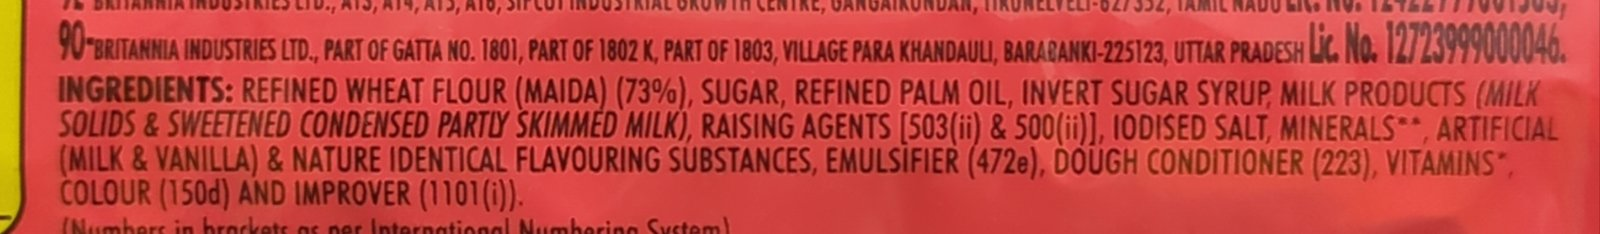

OCR engine: RapidOCR (PP-OCRv6) | enlarged x 2.57 | rotation 0
OCR text, raw (first 400 chars):
 13, AT4, A1S, AT6, SIFLOT INL
CENIKE, OANOAIKUNDAR,TIKU NELVELI-627352,
INGREDIENTS: REFINED WHEAT FLOUR (MAIDA) (73%), SUGAR, REFINED PALM OIL, INVERT SUGAR SYRUP, MILK PRODUCTS (MILK
SOLIDS & SWEETENED CONDENSED PARTLY SKIMMÉD MILK), RAISING AGENTS [503(ii) & 500(ii)], IODISED SALT, MINERALS**, ARTIFICIAL
(MILK & VANILLA) & NATURE IDENTICAL FLAVOURING SÚBSTANCES, EMULSIFIER (472e), DOUGH CONDITI

After spelling correction (first 400 chars):
 13, AT4, A1S, AT6, SIFLOT INL
CENIKE, OANOAIKUNDAR,TIKU NELVELI-627352,
INGREDIENTS: REFINED WHEAT FLOUR (MAIDA) (73%), SUGAR, REFINED PALM OIL, INVERT SUGAR SYRUP, MILK PRODUCTS (MILK
SOLIDS & SWEETENED CONDENSED PARTLY SKIMÉD MILK), RAISING AGENTS [503(ii) & 500(ii)], IODISED SALT, MINERALS**, ARTIFICIAL
(MILK & VANILLA) & NATURE IDENTICAL FLAVOURING SÚBSTANCES, EMULSIFIER (472e), DOUGH CONDITIO

Section found by: keyword
REFINED WHEAT FLOUR (MAIDA)

In [10]:
from src.ocr.ocr_pipeline import read_image
from src.ocr.ocr_cleanup import fix_additive_codes
from src.ocr.section_extraction import extract_ingredients_section
photo = "data/images/packets/8901063162518.jpg"
display(Image(photo, width=420))
ocr = read_image(photo)
print("OCR engine:", ocr["engine"], "| enlarged x", ocr["scale"], "| rotation", ocr["rotation"])
print("OCR text, raw (first 400 chars):\n", ocr["raw_text"][:400])
print("\nAfter spelling correction (first 400 chars):\n", ocr["text"][:400])
cleaned = fix_additive_codes(ocr["text"])
section = extract_ingredients_section(cleaned)
print("\nSection found by:", section["method"]); print(section["text"])

> **WHAT WE DID:** RapidOCR (PaddleOCR PP-OCRv6 detector + recogniser in ONNX). The photo is enlarged so the small print is ~36 px high, sideways/upside-down photos are detected and turned, words are put in reading order, then a food-dictionary spelling corrector (SymSpell; 6,800 words from 22k real ingredient lists) fixes OCR slips ('maltodexirin' -> 'maltodextrin', 'dextr0se' -> 'dextrose'), a targeted fix repairs additive codes ('I5Od' -> '150d'), and the ingredients section is extracted.
>
> **WHY:** Ingredient lists are the smallest print on a pack; the first version (EasyOCR) read only a median 72% of their words. Correcting OCR words against food vocabulary turns near-misses into dictionary hits.
>
> **INPUT → OUTPUT:** photo → ingredient-list text
>
> **HOW TO EXPLAIN IT IN THE VIVA:** *"Known words (food dictionary + 82k English words) are never changed and corrections can only produce food words, so the corrector cannot invent ingredients."*

### B3. Entity linking

In [11]:
from src.kb.entity_linking import get_linker
linker = get_linker()
tests = [{"text": "INS 330", "label": "INS_CODE"}, {"text": "503(ii)", "label": "INS_CODE"}, {"text": "soy lecithin", "label": "ADDITIVE"},
         {"text": "potasium sorbate", "label": "PRESERVATIVE"}, {"text": "Acidity regulator", "label": "FUNCTION_CLASS"},
         {"text": "glucose syrup", "label": "SUGAR"}]
pd.DataFrame([{**t, **{k: v for k, v in linker.link(t).items() if k in ("link_method", "kb_id", "canonical_name", "function")}} for t in tests])

,text,label,kb_id,canonical_name,function,link_method
0,INS 330,INS_CODE,INS:330,Citric acid,"Antioxidant, Sequestrant",ins_number
1,503(ii),INS_CODE,INS:503ii,Ammonium hydrogen carbonate,,ins_number
2,soy lecithin,ADDITIVE,INS:322,Lecithins,"Antioxidant, Emulsifier",exact_name
3,potasium sorbate,PRESERVATIVE,INS:202,Potassium sorbate,Preservative,fuzzy_name
4,Acidity regulator,FUNCTION_CLASS,CLASS:acidity-regulator,Acidity regulator,Acidity regulator,exact_name
5,glucose syrup,SUGAR,TERM:glucose syrup,glucose syrup,,exact_name


### B4. The complete pipeline: photo in, result out

In [12]:
from src.app.scanner import IngredientScanner
scanner = IngredientScanner("auto")          # hybrid: rules + fine-tuned DistilBERT + fuzzy KB matching
result = scanner.scan_image(photo)
print("NER:", result["ner_model"], "| OCR + analysis time:", result["ocr"]["seconds"], "s")
display(pd.DataFrame(result["entities"])[["text", "label", "source", "canonical_name", "function", "link_method"]])
print(json.dumps(result["summary"]["groups"], indent=1))
print("Hidden names:", result["summary"]["hidden"])
print("Allergens:", result["allergens"])
print("Nutrition read from the photo (per 100 g):", result["nutrition"]["per_100g"])

Loading weights:   0%|          | 0/102 [00:00<?, ?it/s]

Loading weights: 100%|██████████| 102/102 [00:00<00:00, 2179.41it/s]

NER: hybrid (rules + DistilBERT + fuzzy KB) | OCR + analysis time: 3.4 s


,text,label,source,canonical_name,function,link_method
0,REFINED WHEAT FLOUR,INGREDIENT,dictionary,,,category
1,MAIDA,INGREDIENT,dictionary,,,category
2,SUGAR,SUGAR,dictionary,sugar,,exact_name
3,REFINED PALM OIL,FAT,dictionary,,,category
4,INVERT SUGAR SYRUP,SUGAR,dictionary,invert sugar syrup,,exact_name
5,MILK PRODUCTS,INGREDIENT,dictionary,,,category
6,RAISING AGENTS,FUNCTION_CLASS,dictionary,Raising agent,Raising agent,exact_name
7,503(ii),INS_CODE,dictionary,Ammonium hydrogen carbonate,raising agent,ins_number
8,500(ii),INS_CODE,dictionary,Sodium hydrogen carbonate,raising agent,ins_number
9,IODISED SALT,INGREDIENT,dictionary,,,category


{
 "SUGAR": [
  "SUGAR",
  "INVERT SUGAR SYRUP"
 ],
 "SWEETENER": [],
 "FAT": [
  "REFINED PALM OIL"
 ],
 "PRESERVATIVE": [
  "223 (Sodium metabisulphite)"
 ],
 "COLOUR": [
  "150d (Sulphite ammonia caramel)"
 ],
 "ADDITIVE": [
  "503(ii) (Ammonium hydrogen carbonate)",
  "500(ii) (Sodium hydrogen carbonate)",
  "472e (Mono- and diacetyltartaric acid esters of mono- and diglycerides of fatty acids)",
  "1101(i)"
 ],
 "FLAVOURING": [
  "NATURE IDENTICAL FLAVOURING S\u00daBSTANCES"
 ],
 "INGREDIENT": [
  "REFINED WHEAT FLOUR",
  "MAIDA",
  "MILK PRODUCTS",
  "IODISED SALT",
  "MINERALS",
  "ARTIFICIAL",
  "MILK & VANILLA"
 ]
}
Hidden names: {'sugars_under_other_names': [], 'fats_under_other_names': [], 'additives_written_as_codes': ['503(ii)', '500(ii)', '472e', '223', '150d', '1101(i)'], 'sugar_like_carbohydrates': []}
Allergens: {'contains': {'Cereals containing gluten': ['maida', 'wheat'], 'Milk': ['milk'], 'Sulphites': ['223']}, 'may_contain': {}}
Nutrition read from the photo (per 1

> **WHAT WE DID:** A hybrid classifier. Exact dictionary/regex/head-word matches are kept (very precise); unknown list items take the DistilBERT label when the model predicts a specific category; still-unknown items are fuzzy-matched to the knowledge base ('glucose syrop' -> glucose syrup -> SUGAR); context rules use the declared class ('Colour (caramel)' -> COLOUR, 'vegetable oil (palm)' -> FAT).
>
> **WHY:** Rules are precise but brittle; the model generalises to unseen spellings; fuzzy matching catches what both miss. Each entity records which component labelled it (`source`), so every decision can be explained.
>
> **INPUT → OUTPUT:** ingredient-list text → entities with category, source, knowledge-base link
>
> **HOW TO EXPLAIN IT IN THE VIVA:** *"The hybrid never lets the model or fuzzy matcher overrule an exact dictionary match, and ignores warnings such as 'PHENYLKETONURICS: contains phenylalanine'."*

### B5. End-to-end evaluation on 60 real photos (held-out test products)

In [13]:
e2e = load("reports/ocr_end_to_end.json")
v1 = load("reports/ocr_easyocr_v1/ocr_end_to_end.json")      # first version: EasyOCR, no correction
print("Photos:", e2e["photos"])
display(pd.DataFrame({"v1 (EasyOCR)": v1["ocr"], "v2 (RapidOCR + correction)": e2e["ocr"]}).drop(["section_methods", "by_market_median_word_recall_full_ocr"]))
rows = {}
for name, report in (("v1", v1), ("v2", e2e)):
    for s, v in report["systems"].items():
        rows[f"{name}: {s}"] = {"entities fuzzy F1": v["entities_fuzzy"]["f1"], "additive numbers P": v["additive_numbers"]["precision"],
                                "additive numbers R": v["additive_numbers"]["recall"], "additive numbers F1": v["additive_numbers"]["f1"]}
display(pd.DataFrame(rows).T)

Photos: 60


,v1 (EasyOCR),v2 (RapidOCR + correction)
median_cer_section,0.638,0.223
median_word_recall_full_ocr,0.72,0.955
median_word_recall_section,0.687,0.917
photos_readable (full-text word recall >= 0.5),42,55


,entities fuzzy F1,additive numbers P,additive numbers R,additive numbers F1
v1: dictionary,0.507,0.957,0.412,0.576
v1: crf,0.498,0.934,0.444,0.602
v1: bert,0.501,0.959,0.444,0.607
v1: distilbert,0.507,0.959,0.444,0.607
v1: distilbert_aug,0.515,0.974,0.475,0.639
v1: distilbert_crf,0.504,0.959,0.438,0.601
v2: dictionary,0.794,0.963,0.812,0.881
v2: crf,0.779,0.940,0.787,0.857
v2: hybrid (app),0.770,0.923,0.819,0.868


* **CER** = character error rate of the extracted section against the product's typed ingredient list.
  The reference was typed by Open Food Facts contributors and may differ slightly from the photo.
* **Entity F1** compares (label, text) bags. *Fuzzy* accepts small spelling differences.
* **Additive numbers**: which additives the app identifies (through codes or names), compared with the reference.

### B6. Daily intake guide: is this amount OK?

In [14]:
from src.app.intake import PROFILES, additive_guidance, assess_portion, headline, special_notes
from src.app.nutrition import estimate_from_similar_product
text = "Sugar, Palm Oil, Hazelnuts (13%), Skimmed Milk Powder (8.7%), Fat-Reduced Cocoa (7.4%), Emulsifier: Lecithins (Soya), Vanillin."
nutella = scanner.scan_text(text)
estimate = estimate_from_similar_product(text)          # no nutrition table in the text -> most similar OFF product
print("Estimated from:", estimate["product_name"], "| similarity", estimate["similarity"])
rows = assess_portion(estimate["per_100g"], portion_g=30, profile=PROFILES["Adult (2000 kcal)"])
print(headline(rows, 30)[0])
display(pd.DataFrame(rows)[["nutrient", "per_100g", "in_portion", "daily_value", "share", "traffic_light", "max_product_g", "message"]])
display(pd.DataFrame(additive_guidance(result["entities"], body_weight_kg=60)))

Estimated from: nutella - Ferrero | similarity 1.0
30 g fits in a day, but uses 34% of the daily limit for sugars; the product is high in sugars, saturated fat, fat per 100 g.


,nutrient,per_100g,in_portion,daily_value,share,traffic_light,max_product_g,message
0,Sugars,56.30,16.9,50.0,0.337800,high,89.0,a large part of the daily limit - keep the rest of the day low in it ≈ 4.2 teaspoons of sugar
1,Salt,0.11,0.0,5.0,0.006600,low,4545.0,a small part of the daily limit
2,Saturated fat,10.60,3.2,22.0,0.144545,high,208.0,a moderate part of the daily limit
3,Fat,30.90,9.3,67.0,0.138358,high,217.0,a moderate part of the daily limit
4,Energy,539.00,161.7,2000.0,0.080850,,NaN,8% of a typical day's energy
5,Carbohydrate,57.50,17.2,260.0,0.066346,,NaN,7% of a typical day's carbohydrate
6,Protein,6.30,1.9,50.0,0.037800,,NaN,4% of the recommended daily amount (more is good)


,additive,group,adi_mg_per_kg,daily_limit,authority,note
0,Ammonium hydrogen carbonate (INS 503ii),Low-concern additive group,NaN,No numerical limit needed (ADI 'not specified'),JECFA / EFSA,"No numerical ADI was needed ('ADI not specified'): at the levels used in food, regulators found no safety ..."
1,Sodium hydrogen carbonate (INS 500ii),Low-concern additive group,NaN,No numerical limit needed (ADI 'not specified'),JECFA / EFSA,"No numerical ADI was needed ('ADI not specified'): at the levels used in food, regulators found no safety ..."
2,Sodium metabisulphite (INS 223),Sulphur dioxide and sulphites,0.7,0.7 mg per kg body weight per day → about 42 mg/day for 60 kg (as sulphur dioxide),JECFA (1998) and EFSA (2016),Can trigger reactions in some people with asthma; must be declared as an allergen above 10 mg/kg.
3,Sulphite ammonia caramel (INS 150d),Caramel colours III and IV,200.0,"200 mg per kg body weight per day → about 12,000 mg/day for 60 kg",JECFA (1985),


> **WHAT WE DID:** For a chosen portion and person profile, each nutrient is compared with official daily reference values: WHO free sugars < 10% of energy (ideally < 5%), WHO salt < 5 g, WHO saturated fat < 10% and trans fat < 1% of energy, EU Reference Intakes (Regulation 1169/2011), UK FSA traffic lights per 100 g. Additives with an INS number get their acceptable daily intake (JECFA / EFSA) scaled to body weight.
>
> **WHY:** Users want to know whether the amount they eat is a small or large part of a day's limit, and how much of the product alone would reach it.
>
> **INPUT → OUTPUT:** nutrition per 100 g (read from the photo, estimated from the most similar of ~9,000 OFF products, or typed), portion, profile → share of each daily limit, traffic light, maximum amount, ADI table
>
> **HOW TO EXPLAIN IT IN THE VIVA:** *"Reference values for healthy people from cited authorities - general information, not medical advice. Total sugars on labels include natural sugars, so the sugar comparison is an upper estimate."*

### B7. The app

```bash
streamlit run src/app/streamlit_app.py
```

Tabs: **Upload photo** (with rotate/crop), **Camera**, **Paste text**, **Example packets** (the 60 real photos).
The text read from a photo is shown and can be corrected and re-analysed. Sections: what is in it, allergens,
daily intake guide, details. Deployment: `Dockerfile` and `docs/DEPLOYMENT.md`.

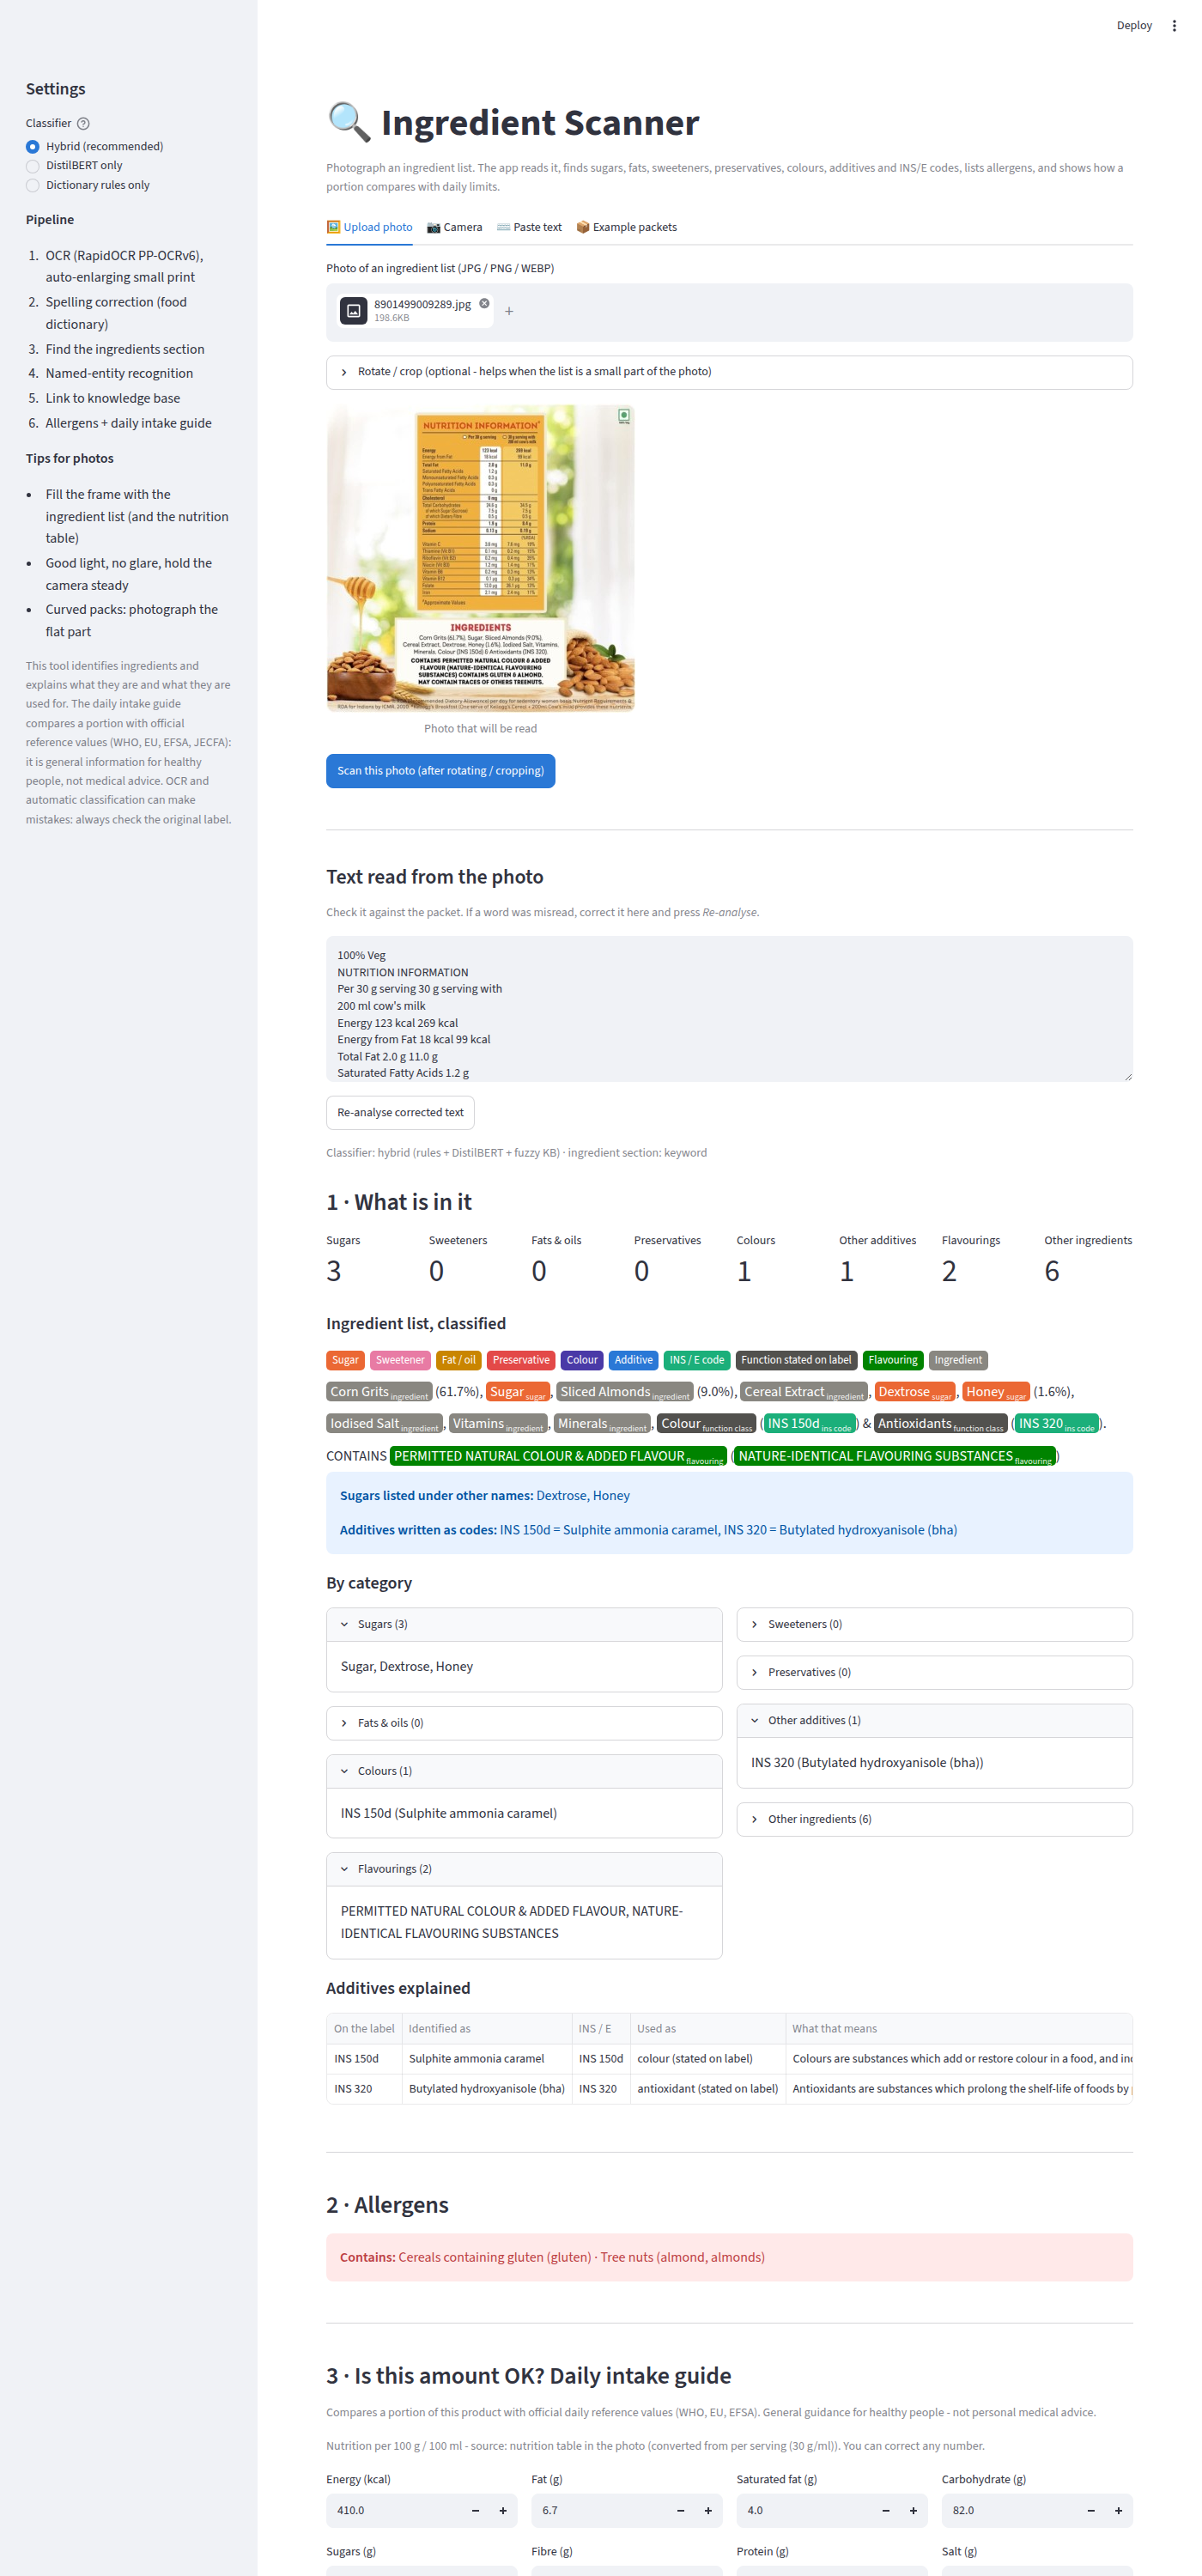

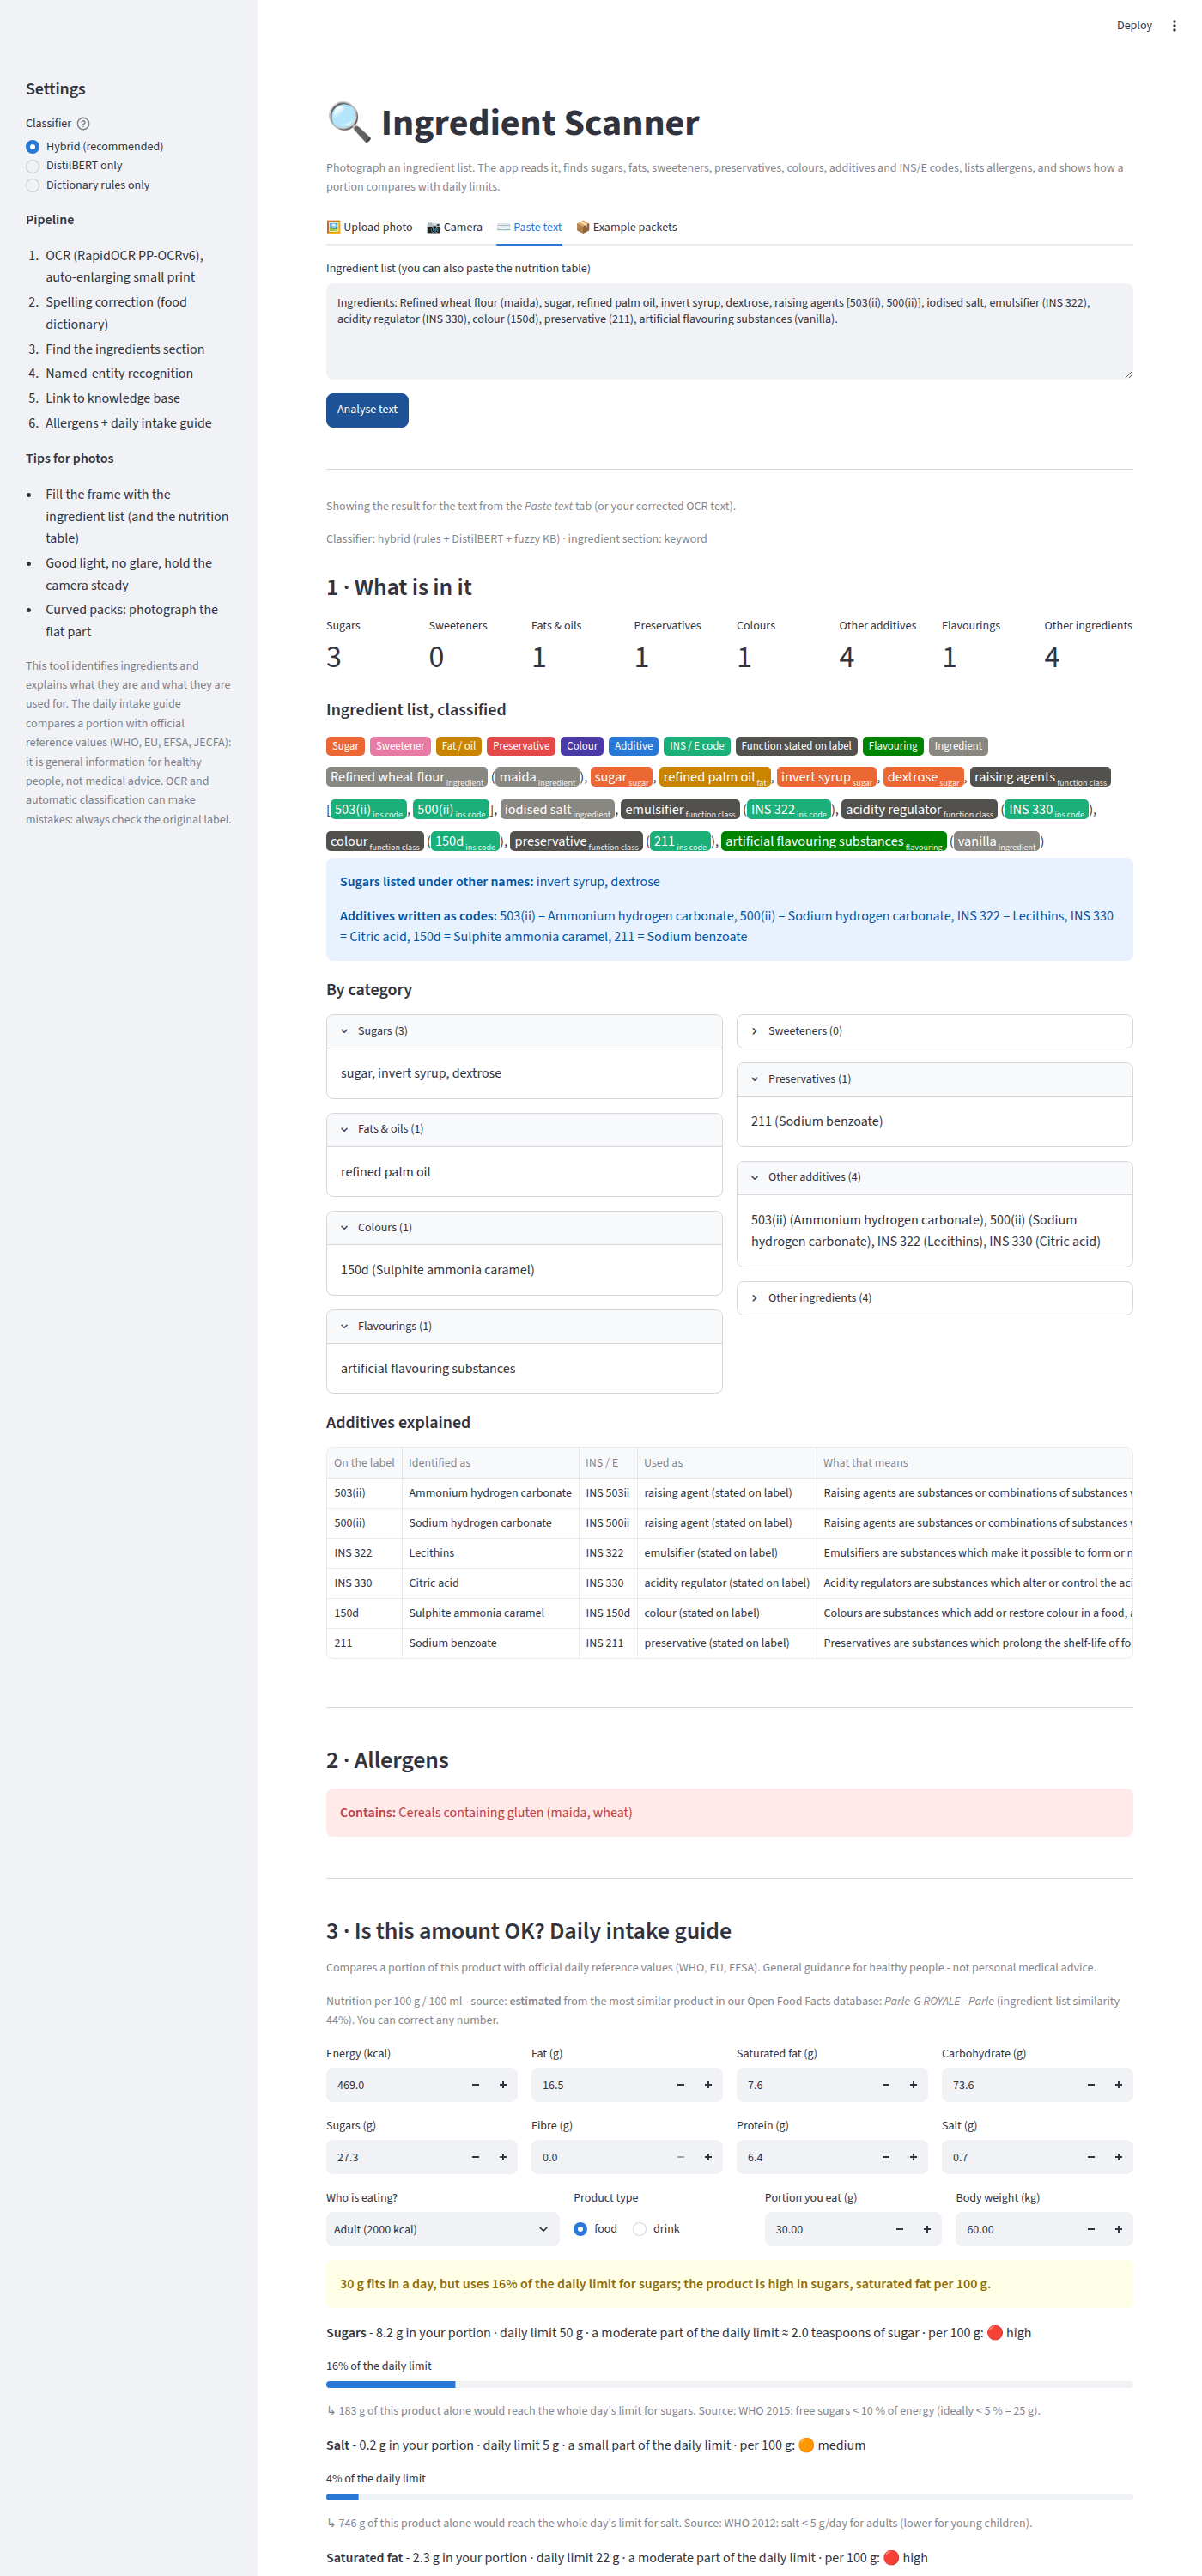

In [15]:
for shot in sorted(Path("reports/figures").glob("app_*.png")):
    display(Image(str(shot), width=900))

## Limitations

* **Silver supervision.** Models learn the rules' policy, including some of their mistakes. Final claims
  need the human gold test set.
* **CPU training.** 8,000 sentences, 1–2 epochs. More data or epochs would likely help.
* **OCR.** Curved cans/bottles, glare and very small or blurred print still cause errors (5 of the 60 test
  photos remain unreadable). The app warns about hard photos and lets the user crop or correct the text.
  The photo reference text is crowd-typed.
* **Missing separators.** When OCR loses all commas (second example in A5), neither the rules nor the
  model split the ingredients correctly.
* **English only.** Labels in other languages or scripts are not handled.
* **Daily intake guide.** Uses general reference values for healthy people; nutrition values may be
  estimated from a similar product (clearly labelled) and additive amounts are rarely on labels.
  It is information, not medical advice.